# 03 — FAG-TFT Forecaster
### Frequency-Aware Gated Temporal Fusion Transformer — Event-Based Breakdown Forecasting
> Run 00_Data_Preparation.ipynb first.
>
> **Model A:** Binary forecaster (breakdown coming within H=15 events?)
> **Model B:** Type forecaster (which breakdown type is coming?)
>
> FAG architecture groups features by frequency band before TFT processing.


In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, mean_squared_error, mean_absolute_error,
    recall_score, precision_score
)
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')


✅ Device: cpu


In [2]:
with open('prepared_forecasting.pkl','rb') as f: d = pickle.load(f)
with open('encoder_reason.pkl','rb') as f: encoder_reason = pickle.load(f)

X_train      = torch.FloatTensor(d['X_fc_train_seq']).to(DEVICE)
X_test       = torch.FloatTensor(d['X_fc_test_seq']).to(DEVICE)
y_train_bin  = torch.LongTensor(d['y_fc_train_bin_seq']).to(DEVICE)
y_test_bin   = torch.LongTensor(d['y_fc_test_bin_seq']).to(DEVICE)
y_train_type = torch.LongTensor(d['y_fc_train_type_seq']).to(DEVICE)
y_test_type  = torch.LongTensor(d['y_fc_test_type_seq']).to(DEVICE)

NUM_FEATURES       = d['num_features']
TIME_STEPS         = d['TIME_STEPS']
H                  = d['H']
NUM_REASON_CLASSES = d['num_reason_classes']

# Frequency group indices — same as FAG-TFT classifier
G1_IDX = list(range(0,  9))   # Low Freq  (10-100Hz)  — 9 bands
G2_IDX = list(range(9,  29))  # Mid Freq  (100-300Hz) — 20 bands
G3_IDX = list(range(29, 60))  # High Freq (300-610Hz) — 31 bands
EL_IDX = list(range(60, 67))  # Electrical + time_gap — 7 features

# Binary class counts
cc_bin = np.bincount(d['y_fc_train_bin_seq'])

train_loader_bin = DataLoader(
    TensorDataset(X_train, y_train_bin),
    batch_size=32, shuffle=True
)

print(f'✅ Data loaded.')
print(f'   Features   : {NUM_FEATURES}, TIME_STEPS: {TIME_STEPS}, H: {H}')
print(f'   Binary class counts : {cc_bin}')
print(f'   Safe %              : {(d["y_fc_train_bin_seq"]==0).mean()*100:.1f}%')
print(f'   Breakdown %         : {(d["y_fc_train_bin_seq"]==1).mean()*100:.1f}%')
print(f'   Reason classes      : {list(encoder_reason.classes_)}')
print(f'   G1 Low Freq  : {len(G1_IDX)} bands')
print(f'   G2 Mid Freq  : {len(G2_IDX)} bands')
print(f'   G3 High Freq : {len(G3_IDX)} bands')
print(f'   Electrical   : {len(EL_IDX)} features')


✅ Data loaded.
   Features   : 67, TIME_STEPS: 20, H: 15
   Binary class counts : [9622 2418]
   Safe %              : 79.9%
   Breakdown %         : 20.1%
   Reason classes      : ['High Thread Tension', 'High foot pressure', 'No Breakdown', 'Running with no thread']
   G1 Low Freq  : 9 bands
   G2 Mid Freq  : 20 bands
   G3 High Freq : 31 bands
   Electrical   : 7 features


---
## FAG-TFT Forecaster Architecture
> Frequency-Aware Gated input projection replaces standard GRN.
> Features grouped by frequency band — Low, Mid, High Freq + Electrical.
> hidden_size=64, num_heads=4, 2 LSTM layers, dropout=0.3


In [3]:
class GRN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()
        self.fc1        = nn.Linear(input_size, hidden_size)
        self.fc2        = nn.Linear(hidden_size, output_size)
        self.gate_fc    = nn.Linear(hidden_size, output_size)
        self.elu        = nn.ELU()
        self.sigmoid    = nn.Sigmoid()
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(output_size)
        self.residual   = nn.Linear(input_size, output_size) if input_size != output_size else nn.Identity()

    def forward(self, x):
        h    = self.elu(self.fc1(x))
        h    = self.dropout(h)
        gate = self.sigmoid(self.gate_fc(h))
        out  = gate * self.fc2(h)
        return self.layer_norm(out + self.residual(x))


class HierarchicalVSN(nn.Module):
    """Frequency-Aware Gated input projection for the forecaster."""
    def __init__(self, g1_size, g2_size, g3_size, el_size, hidden_size, dropout=0.1):
        super().__init__()
        self.grn_g1 = GRN(g1_size, hidden_size, hidden_size, dropout)
        self.grn_g2 = GRN(g2_size, hidden_size, hidden_size, dropout)
        self.grn_g3 = GRN(g3_size, hidden_size, hidden_size, dropout)
        self.grn_el = GRN(el_size, hidden_size, hidden_size, dropout)
        self.sel_g1 = nn.Linear(hidden_size, hidden_size)
        self.sel_g2 = nn.Linear(hidden_size, hidden_size)
        self.sel_g3 = nn.Linear(hidden_size, hidden_size)
        self.sel_el = nn.Linear(hidden_size, hidden_size)
        self.across_grn  = GRN(hidden_size * 4, hidden_size, 4, dropout)
        self.group_merge = nn.Linear(hidden_size * 4, hidden_size)

    def forward(self, x_g1, x_g2, x_g3, x_el):
        h1 = self.grn_g1(x_g1); h2 = self.grn_g2(x_g2)
        h3 = self.grn_g3(x_g3); he = self.grn_el(x_el)
        w1 = torch.sigmoid(self.sel_g1(h1)); w2 = torch.sigmoid(self.sel_g2(h2))
        w3 = torch.sigmoid(self.sel_g3(h3)); we = torch.sigmoid(self.sel_el(he))
        h1, h2, h3, he = w1*h1, w2*h2, w3*h3, we*he
        concat    = torch.cat([h1, h2, h3, he], dim=-1)
        g_weights = F.softmax(self.across_grn(concat), dim=-1)
        self.group_weights = g_weights.detach().cpu()
        merged = (g_weights[:,0:1]*h1 + g_weights[:,1:2]*h2 +
                  g_weights[:,2:3]*h3 + g_weights[:,3:4]*he)
        return self.group_merge(concat) + merged


class FAG_TFT_Forecaster(nn.Module):
    """FAG-TFT Forecaster — frequency-aware gated input projection + TFT encoder."""
    def __init__(self, g1_size, g2_size, g3_size, el_size,
                 time_steps, num_classes, hidden_size=64, num_heads=4, dropout=0.3):
        super().__init__()
        self.time_steps = time_steps
        self.g1_size = g1_size; self.g2_size = g2_size
        self.g3_size = g3_size; self.el_size = el_size
        # FAG input projection — replaces standard GRN
        self.vsn           = HierarchicalVSN(g1_size, g2_size, g3_size, el_size, hidden_size, dropout)
        self.lstm_encoder  = nn.LSTM(hidden_size, hidden_size, 2,
                                     batch_first=True, dropout=dropout)
        self.attention     = nn.MultiheadAttention(hidden_size, num_heads,
                                                    dropout=dropout, batch_first=True)
        self.attn_norm     = nn.LayerNorm(hidden_size)
        self.post_attn_grn = GRN(hidden_size, hidden_size, hidden_size, dropout)
        self.classifier    = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, num_classes)
        )

    def forward(self, x):
        vsn_out = []
        for t in range(self.time_steps):
            xt = x[:, t, :]
            g1 = xt[:, :self.g1_size]
            g2 = xt[:, self.g1_size:self.g1_size+self.g2_size]
            g3 = xt[:, self.g1_size+self.g2_size:self.g1_size+self.g2_size+self.g3_size]
            el = xt[:, self.g1_size+self.g2_size+self.g3_size:]
            vsn_out.append(self.vsn(g1, g2, g3, el))
        vsn_seq     = torch.stack(vsn_out, dim=1)
        lstm_out, _ = self.lstm_encoder(vsn_seq)
        attn_out, self.attn_weights = self.attention(lstm_out, lstm_out, lstm_out)
        attn_out    = self.attn_norm(attn_out + lstm_out)
        out         = self.post_attn_grn(attn_out[:, -1, :])
        return self.classifier(out)


---
## Model A — Binary Forecaster
> Predicts: will a breakdown happen within the next H=15 events?


In [4]:
model_a = FAG_TFT_Forecaster(
    g1_size=len(G1_IDX), g2_size=len(G2_IDX),
    g3_size=len(G3_IDX), el_size=len(EL_IDX),
    time_steps=TIME_STEPS, num_classes=2,
    hidden_size=64, num_heads=4, dropout=0.3
).to(DEVICE)
print(f'FAG-TFT Model A (Binary) parameters: {sum(p.numel() for p in model_a.parameters()):,}')


FAG-TFT Model A (Binary) parameters: 192,054


Training FAG-TFT Model A (Binary Forecaster)...
Epoch   1 | Train: 0.1941 | Val: 0.1410
Epoch   2 | Train: 0.1444 | Val: 0.1505
Epoch   3 | Train: 0.1304 | Val: 0.1383
Epoch   4 | Train: 0.1077 | Val: 0.1701
Epoch   5 | Train: 0.0845 | Val: 0.2308
Epoch   6 | Train: 0.0712 | Val: 0.2600
Epoch   7 | Train: 0.0563 | Val: 0.3328
Epoch   8 | Train: 0.0511 | Val: 0.3224
Epoch   9 | Train: 0.0438 | Val: 0.4079
Epoch  10 | Train: 0.0371 | Val: 0.3530
Epoch  11 | Train: 0.0306 | Val: 0.4564
Epoch  12 | Train: 0.0247 | Val: 0.4437
Epoch  13 | Train: 0.0269 | Val: 0.4416
Epoch  14 | Train: 0.0247 | Val: 0.4606
Epoch  15 | Train: 0.0202 | Val: 0.4933
Epoch  16 | Train: 0.0187 | Val: 0.4577
Epoch  17 | Train: 0.0129 | Val: 0.5538
Early stopping at epoch 18

✅ Best val loss: 0.1383 — best checkpoint restored.


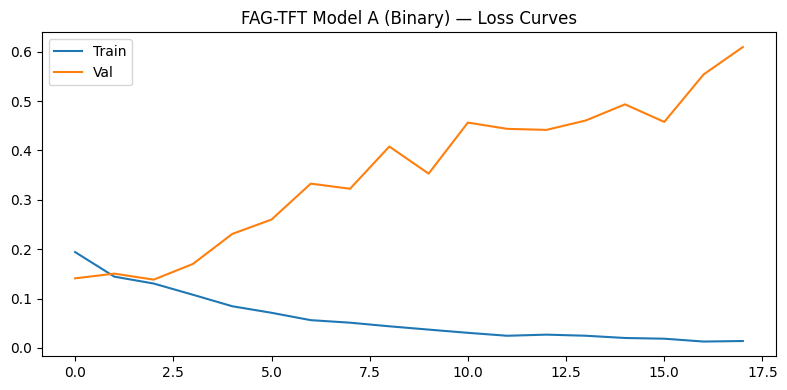

In [5]:
EPOCHS    = 50
optimizer = torch.optim.Adam(model_a.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

best_val_loss    = float('inf')
patience_counter = 0
PATIENCE         = 15
train_losses, val_losses = [], []

print('Training FAG-TFT Model A (Binary Forecaster)...')
for epoch in range(EPOCHS):
    model_a.train()
    batch_losses = []
    for xb, yb in train_loader_bin:
        optimizer.zero_grad()
        loss = criterion(model_a(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_a.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    scheduler.step()

    model_a.eval()
    with torch.no_grad():
        val_loss = criterion(model_a(X_test), y_test_bin).item()
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_a.state_dict(), 'best_tft_binary.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

model_a.load_state_dict(torch.load('best_tft_binary.pt'))
print(f'\n✅ Best val loss: {best_val_loss:.4f} — best checkpoint restored.')

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('FAG-TFT Model A (Binary) — Loss Curves')
plt.legend(); plt.tight_layout()
plt.savefig('tft_binary_loss.png', dpi=150); plt.show()


#### Evaluate Model A


FAG-TFT MODEL A — BINARY FORECASTER RESULTS
Accuracy : 96.13%
F1 Score : 0.9603
RMSE     : 0.1968
MAE      : 0.0387

                  precision    recall  f1-score   support

            Safe       0.96      0.99      0.98      2410
Breakdown Coming       0.95      0.84      0.89       585

        accuracy                           0.96      2995
       macro avg       0.96      0.92      0.94      2995
    weighted avg       0.96      0.96      0.96      2995



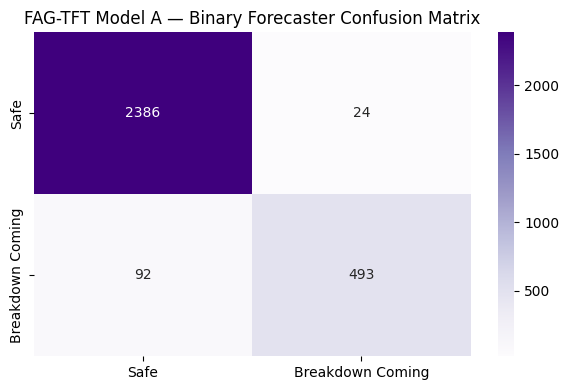

THRESHOLD ANALYSIS
 Threshold | Accuracy | BD Recall | BD Precision |     F1
-------------------------------------------------------
      0.50 |   96.13% |      0.84 |         0.95 | 0.9603
      0.40 |   95.76% |      0.85 |         0.93 | 0.9569
      0.30 |   95.63% |      0.86 |         0.91 | 0.9558
      0.25 |   95.46% |      0.87 |         0.90 | 0.9543
      0.20 |   95.16% |      0.87 |         0.88 | 0.9515
      0.15 |   94.59% |      0.87 |         0.85 | 0.9461
      0.10 |   93.06% |      0.88 |         0.79 | 0.9320

✅ Best threshold: 0.5 (F1=0.9603)
✅ Model A results saved.


In [6]:
model_a.eval()
with torch.no_grad():
    probs_all       = torch.softmax(model_a(X_test), dim=1).cpu().numpy()
    y_pred_bin      = np.argmax(probs_all, axis=1)
    y_true_bin      = y_test_bin.cpu().numpy()
    breakdown_probs = probs_all[:, 1]

acc  = accuracy_score(y_true_bin, y_pred_bin)
f1   = f1_score(y_true_bin, y_pred_bin, average='weighted')
rmse = np.sqrt(mean_squared_error(y_true_bin, y_pred_bin))
mae  = mean_absolute_error(y_true_bin, y_pred_bin)

print('='*55)
print('FAG-TFT MODEL A — BINARY FORECASTER RESULTS')
print('='*55)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')
print()
print(classification_report(y_true_bin, y_pred_bin, target_names=['Safe','Breakdown Coming']))

cm = confusion_matrix(y_true_bin, y_pred_bin)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Safe','Breakdown Coming'],
            yticklabels=['Safe','Breakdown Coming'])
plt.title('FAG-TFT Model A — Binary Forecaster Confusion Matrix')
plt.tight_layout()
plt.savefig('tft_binary_confusion.png', dpi=150); plt.show()

# Threshold analysis
print('='*55)
print('THRESHOLD ANALYSIS')
print('='*55)
print(f'{"Threshold":>10} | {"Accuracy":>8} | {"BD Recall":>9} | {"BD Precision":>12} | {"F1":>6}')
print('-'*55)
best_threshold = 0.5; best_f1 = 0; threshold_results = []
for threshold in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
    y_pred_t = (breakdown_probs >= threshold).astype(int)
    acc_t    = accuracy_score(y_true_bin, y_pred_t)
    f1_t     = f1_score(y_true_bin, y_pred_t, average='weighted')
    rec_bd   = recall_score(y_true_bin, y_pred_t, pos_label=1)
    pre_bd   = precision_score(y_true_bin, y_pred_t, pos_label=1, zero_division=0)
    print(f'{threshold:>10.2f} | {acc_t*100:>7.2f}% | {rec_bd:>9.2f} | {pre_bd:>12.2f} | {f1_t:>6.4f}')
    threshold_results.append((threshold, acc_t, rec_bd, pre_bd, f1_t))
    if f1_t > best_f1: best_f1 = f1_t; best_threshold = threshold
print(f'\n✅ Best threshold: {best_threshold} (F1={best_f1:.4f})')

tft_binary_results = {'model':'FAG-TFT Forecaster','accuracy':acc,'f1':f1,'rmse':rmse,'mae':mae,'best_threshold':best_threshold}
with open('tft_binary_results.pkl','wb') as f: pickle.dump(tft_binary_results, f)
print('✅ Model A results saved.')


---
## Model B — Type Forecaster
> Trained only on records where breakdown IS coming.
> Predicts which breakdown type is approaching.


In [7]:
mask_train = d['y_fc_train_bin_seq'] == 1
mask_test  = d['y_fc_test_bin_seq'] == 1

X_tr_type = torch.FloatTensor(d['X_fc_train_seq'][mask_train]).to(DEVICE)
X_te_type = torch.FloatTensor(d['X_fc_test_seq'][mask_test]).to(DEVICE)
y_tr_type = torch.LongTensor(d['y_fc_train_type_seq'][mask_train]).to(DEVICE)
y_te_type = torch.LongTensor(d['y_fc_test_type_seq'][mask_test]).to(DEVICE)

unique_types_train = np.unique(d['y_fc_train_type_seq'][mask_train])
print(f'✅ Type forecaster data ready.')
print(f'   Train: {X_tr_type.shape}  Test: {X_te_type.shape}')
print(f'   Unique breakdown types in train: {unique_types_train}')

if len(unique_types_train) > 1:
    cc_type  = np.bincount(d['y_fc_train_type_seq'][mask_train])
    cw_type  = np.where(cc_type > 0, 1.0 / cc_type, 0.0)
    cw_type  = cw_type / cw_type[cw_type > 0].sum() * (cc_type > 0).sum()
    weights_type = torch.FloatTensor(cw_type).to(DEVICE)
    print(f'   Type class counts  : {cc_type}')
    print(f'   Type class weights : {cw_type.round(3)}')
else:
    weights_type = torch.ones(NUM_REASON_CLASSES, dtype=torch.float32).to(DEVICE)
    print('⚠️  Only one breakdown type — using uniform weights.')

train_loader_type = DataLoader(TensorDataset(X_tr_type, y_tr_type), batch_size=32, shuffle=True)


✅ Type forecaster data ready.
   Train: torch.Size([2418, 20, 67])  Test: torch.Size([585, 20, 67])
   Unique breakdown types in train: [0 1 3]
   Type class counts  : [810 810   0 798]
   Type class weights : [0.995 0.995 0.    1.01 ]


FAG-TFT Model B (Type) parameters: 192,120
Training FAG-TFT Model B (Type Forecaster)...
Epoch   1 | Train: 0.4926 | Val: 0.2374
Epoch   2 | Train: 0.1473 | Val: 0.3046
Epoch   3 | Train: 0.0753 | Val: 0.4569
Epoch   4 | Train: 0.0503 | Val: 0.6199
Epoch   5 | Train: 0.0399 | Val: 0.4759
Epoch   6 | Train: 0.0192 | Val: 0.6132
Epoch   7 | Train: 0.0121 | Val: 0.6700
Epoch   8 | Train: 0.0151 | Val: 0.6232
Epoch   9 | Train: 0.0128 | Val: 0.7897
Epoch  10 | Train: 0.0026 | Val: 0.7304
Epoch  11 | Train: 0.0023 | Val: 0.7987
Epoch  12 | Train: 0.0070 | Val: 0.8154
Epoch  13 | Train: 0.0153 | Val: 0.7401
Epoch  14 | Train: 0.0067 | Val: 0.8263
Epoch  15 | Train: 0.0011 | Val: 0.8415
Early stopping at epoch 16

✅ Best val loss: 0.2374 — best checkpoint restored.


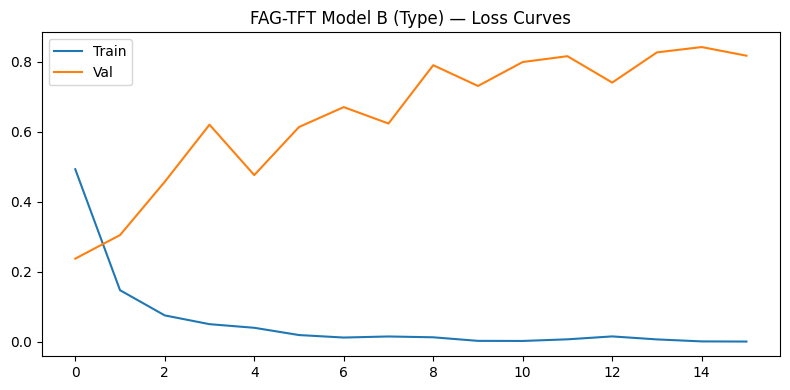

In [8]:
model_b = FAG_TFT_Forecaster(
    g1_size=len(G1_IDX), g2_size=len(G2_IDX),
    g3_size=len(G3_IDX), el_size=len(EL_IDX),
    time_steps=TIME_STEPS, num_classes=NUM_REASON_CLASSES,
    hidden_size=64, num_heads=4, dropout=0.3
).to(DEVICE)
print(f'FAG-TFT Model B (Type) parameters: {sum(p.numel() for p in model_b.parameters()):,}')

EPOCHS      = 50
optimizer_b = torch.optim.Adam(model_b.parameters(), lr=1e-3)
criterion_b = nn.CrossEntropyLoss(weight=weights_type)
scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=50)

best_val_loss_b = float('inf')
patience_b      = 0
PATIENCE_B      = 15
train_losses_b, val_losses_b = [], []

print('Training FAG-TFT Model B (Type Forecaster)...')
for epoch in range(EPOCHS):
    model_b.train()
    batch_losses = []
    for xb, yb in train_loader_type:
        optimizer_b.zero_grad()
        loss = criterion_b(model_b(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_b.parameters(), 1.0)
        optimizer_b.step()
        batch_losses.append(loss.item())
    scheduler_b.step()

    model_b.eval()
    with torch.no_grad():
        val_loss = criterion_b(model_b(X_te_type), y_te_type).item()
    train_loss = np.mean(batch_losses)
    train_losses_b.append(train_loss)
    val_losses_b.append(val_loss)

    if val_loss < best_val_loss_b:
        best_val_loss_b = val_loss
        torch.save(model_b.state_dict(), 'best_tft_type.pt')
        patience_b = 0
    else:
        patience_b += 1
        if patience_b >= PATIENCE_B:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

model_b.load_state_dict(torch.load('best_tft_type.pt'))
print(f'\n✅ Best val loss: {best_val_loss_b:.4f} — best checkpoint restored.')

plt.figure(figsize=(8,4))
plt.plot(train_losses_b, label='Train')
plt.plot(val_losses_b, label='Val')
plt.title('FAG-TFT Model B (Type) — Loss Curves')
plt.legend(); plt.tight_layout()
plt.savefig('tft_type_loss.png', dpi=150); plt.show()


#### Evaluate Model B


FAG-TFT MODEL B — TYPE FORECASTER RESULTS
Accuracy : 91.79%
F1 Score : 0.9190

                        precision    recall  f1-score   support

   High Thread Tension       0.83      0.96      0.89       195
    High foot pressure       0.97      0.89      0.93       195
Running with no thread       0.98      0.90      0.94       195

              accuracy                           0.92       585
             macro avg       0.93      0.92      0.92       585
          weighted avg       0.93      0.92      0.92       585



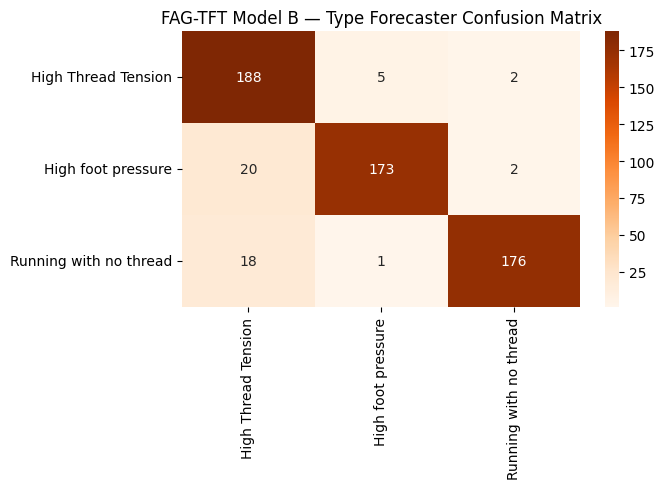

✅ Model B results saved.


In [9]:
model_b.eval()
with torch.no_grad():
    y_pred_type = np.argmax(torch.softmax(model_b(X_te_type), dim=1).cpu().numpy(), axis=1)
    y_true_type = y_te_type.cpu().numpy()

unique_labels = sorted(set(y_true_type) | set(y_pred_type))
label_names   = [encoder_reason.classes_[i] for i in unique_labels]

print('='*50)
print('FAG-TFT MODEL B — TYPE FORECASTER RESULTS')
print('='*50)
print(f'Accuracy : {accuracy_score(y_true_type, y_pred_type)*100:.2f}%')
print(f'F1 Score : {f1_score(y_true_type, y_pred_type, average="weighted"):.4f}')
print()
print(classification_report(y_true_type, y_pred_type, labels=unique_labels, target_names=label_names))

cm = confusion_matrix(y_true_type, y_pred_type, labels=unique_labels)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names)
plt.title('FAG-TFT Model B — Type Forecaster Confusion Matrix')
plt.tight_layout()
plt.savefig('tft_type_confusion.png', dpi=150); plt.show()

tft_type_results = {
    'model'   : 'FAG-TFT Forecaster Type',
    'accuracy': accuracy_score(y_true_type, y_pred_type),
    'f1'      : f1_score(y_true_type, y_pred_type, average='weighted'),
}
with open('tft_type_results.pkl','wb') as f: pickle.dump(tft_type_results, f)
print('✅ Model B results saved.')


#### Save Artifacts


In [10]:
tft_forecast_config = {
    'num_features'      : NUM_FEATURES,
    'time_steps'        : TIME_STEPS,
    'H'                 : H,
    'num_classes_binary': 2,
    'num_classes_type'  : NUM_REASON_CLASSES,
    'hidden_size'       : 64,
    'num_heads'         : 4,
    'g1_size'           : len(G1_IDX),
    'g2_size'           : len(G2_IDX),
    'g3_size'           : len(G3_IDX),
    'el_size'           : len(EL_IDX),
    'G1_IDX'            : G1_IDX,
    'G2_IDX'            : G2_IDX,
    'G3_IDX'            : G3_IDX,
    'EL_IDX'            : EL_IDX,
}
with open('tft_forecast_config.pkl','wb') as f: pickle.dump(tft_forecast_config, f)
print('✅ Saved: best_tft_binary.pt | best_tft_type.pt | tft_forecast_config.pkl')
print('         tft_binary_results.pkl | tft_type_results.pkl')


✅ Saved: best_tft_binary.pt | best_tft_type.pt | tft_forecast_config.pkl
         tft_binary_results.pkl | tft_type_results.pkl
